XAI (SHAP) 


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import io
import matplotlib.font_manager as fm
from PIL import Image, ImageDraw, ImageFont
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score,
    recall_score, accuracy_score, confusion_matrix
)
from scipy.stats import randint, uniform, loguniform

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
shap.initjs()
SEED = 42


/Users/nursultanmurzabaev/Desktop/LAB-3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
 Загрузка данных и воспроизведение пайплайна
> Полная цепочка воспроизводится детерминированно (random_state=42 везде)

In [2]:
TARGET = 'satisfaction'

df_train_raw = pd.read_csv('train.csv')
df_test_raw  = pd.read_csv('test.csv')

for df in [df_train_raw, df_test_raw]:
    df.drop(columns=[c for c in ['Unnamed: 0', 'id'] if c in df.columns], inplace=True)
    df[TARGET] = (df[TARGET] == 'satisfied').astype(int)

X_train = df_train_raw.drop(columns=[TARGET])
y_train = df_train_raw[TARGET]
X_test  = df_test_raw.drop(columns=[TARGET])
y_test  = df_test_raw[TARGET]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

numerical_features   = ['Age', 'Flight Distance',
                         'Departure Delay in Minutes', 'Arrival Delay in Minutes']
categorical_features = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
service_features     = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                              ('scaler',  StandardScaler())]),
             numerical_features),
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                              ('encoder', OneHotEncoder(drop='first',
                               handle_unknown='ignore', sparse_output=False))]),
             categorical_features),
            ('svc', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                              ('scaler',  StandardScaler())]),
             service_features)
        ],
        remainder='drop', verbose_feature_names_out=True
    )



Train: (103904, 22) | Test: (25976, 22)


In [3]:
import time

lgbm_param_dist = {
    'classifier__n_estimators':      randint(200, 1001),
    'classifier__learning_rate':     loguniform(0.01, 0.3),
    'classifier__num_leaves':        randint(20, 150),
    'classifier__max_depth':         [-1, 5, 7, 10, 12, 15],
    'classifier__min_child_samples': randint(10, 60),
    'classifier__subsample':         uniform(0.6, 0.4),
    'classifier__colsample_bytree':  uniform(0.5, 0.5),
    'classifier__reg_alpha':         loguniform(1e-4, 1.0),
    'classifier__reg_lambda':        loguniform(1e-4, 1.0),
    'classifier__class_weight':      ['balanced', None]
}

lgbm_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('classifier', LGBMClassifier(
        objective='binary', metric='auc',
        random_state=SEED, n_jobs=-1, verbose=-1
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
lgbm_search = RandomizedSearchCV(
    lgbm_pipeline, lgbm_param_dist,
    n_iter=20, scoring='roc_auc', cv=skf,
    refit=True, n_jobs=-1, random_state=SEED, verbose=0
)

t0 = time.time()
lgbm_search.fit(X_train, y_train)

lgbm_best = lgbm_search.best_estimator_

---
 SHAP: Подготовка данных и инициализация TreeExplainer

In [4]:
X_sample = X_test.sample(500, random_state=SEED)
y_sample = y_test.loc[X_sample.index]

print(f"Размер SHAP-выборки: {X_sample.shape}")
print(f"Баланс классов: {dict(y_sample.value_counts())}")

Размер SHAP-выборки: (500, 22)
Баланс классов: {0: np.int64(292), 1: np.int64(208)}


In [5]:
preprocessor   = lgbm_best.named_steps['preprocessor']
X_transformed  = preprocessor.transform(X_sample)   

raw_names = preprocessor.get_feature_names_out()

clean_names = [
    name.split('__', 1)[1] if '__' in name else name
    for name in raw_names
]

X_shap_df = pd.DataFrame(X_transformed, columns=clean_names)

print(f"Трансформированная матрица: {X_shap_df.shape}")
print(f"Первые 5 признаков: {clean_names[:5]}")
print(f"Последние 5 признаков: {clean_names[-5:]}")

Трансформированная матрица: (500, 23)
Первые 5 признаков: ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender_Male']
Последние 5 признаков: ['Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']


In [6]:
clf = lgbm_best.named_steps['classifier']

explainer = shap.TreeExplainer(
    clf,
    feature_names=clean_names,  
    model_output='raw'          
)

shap_explanation = explainer(X_shap_df)  

shap_vals = shap_explanation.values

if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 1]
    base_val  = shap_explanation.base_values[:, 1]
else:
    base_val  = shap_explanation.base_values

shap_exp_clean = shap.Explanation(
    values       = shap_vals,
    base_values  = base_val,
    data         = X_shap_df.values,
    feature_names= clean_names
)

print(f" SHAP values shape : {shap_vals.shape}")
print(f"   Base value (avg)  : {base_val.mean():.4f}  (log-odds)")

 SHAP values shape : (500, 23)
   Base value (avg)  : -0.3075  (log-odds)


---
 SHAP Plot 1 — Global Bar Chart 

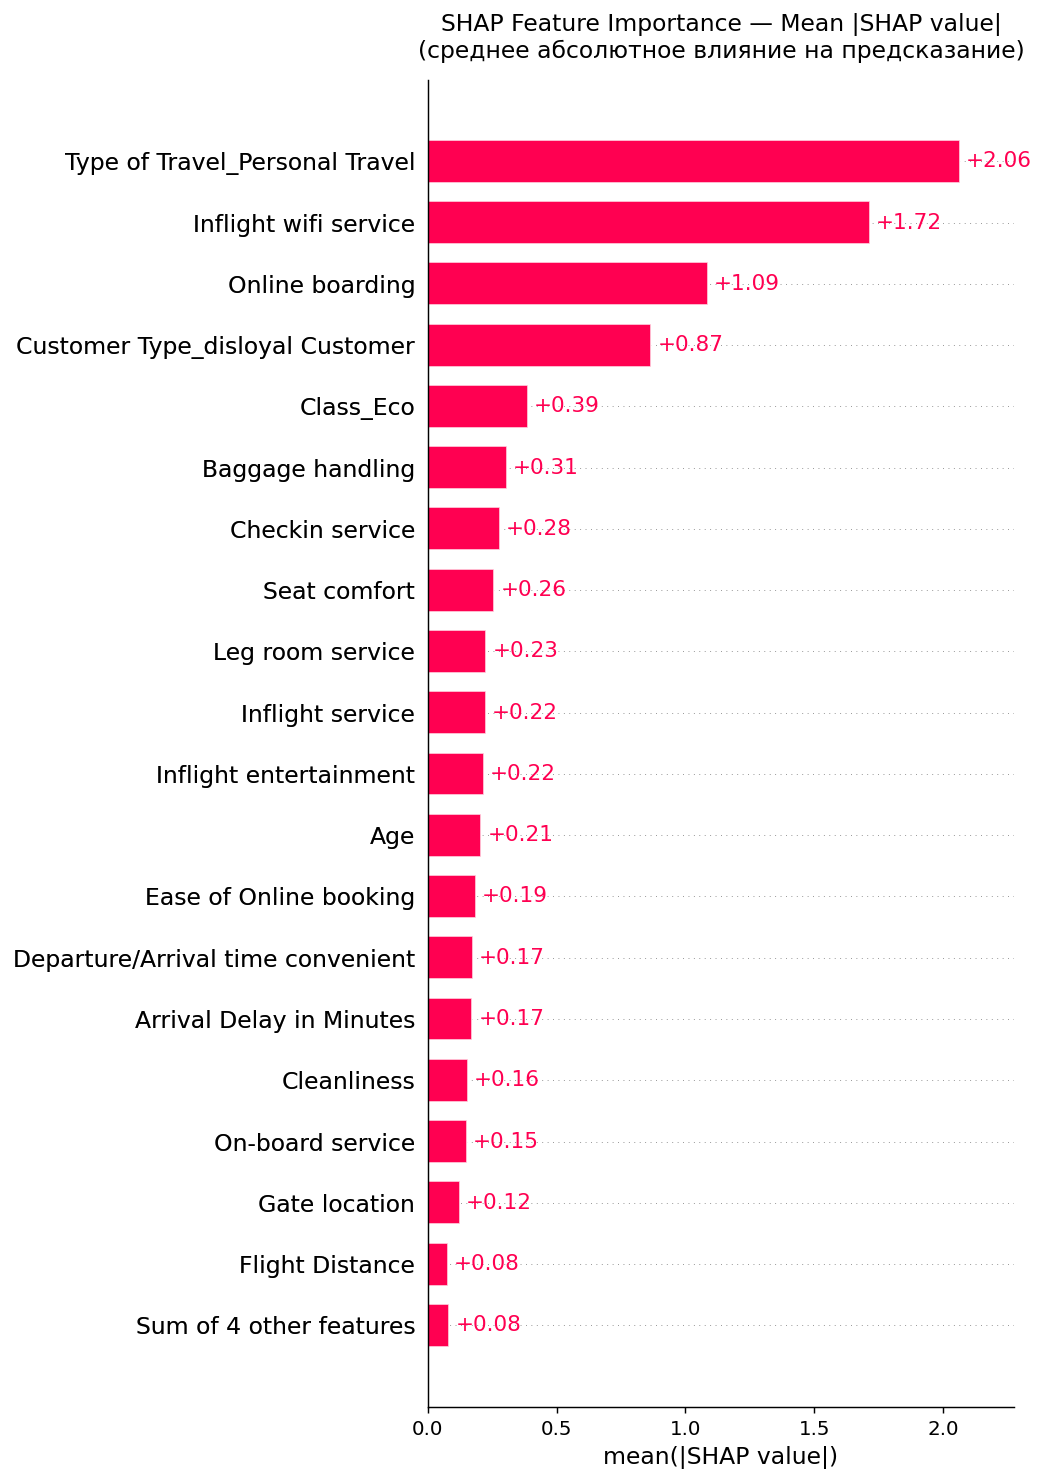


Топ-10 признаков по Mean|SHAP|:
                        Feature  Mean|SHAP|
 Type of Travel_Personal Travel    2.064522
          Inflight wifi service    1.716519
                Online boarding    1.086873
Customer Type_disloyal Customer    0.866769
                      Class_Eco    0.388238
               Baggage handling    0.306785
                Checkin service    0.279914
                   Seat comfort    0.257121
               Leg room service    0.227563
               Inflight service    0.224606


In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.bar(
    shap_exp_clean,
    max_display=20,
    show=False
)
plt.title(
    'SHAP Feature Importance — Mean |SHAP value|\n'
    '(среднее абсолютное влияние на предсказание)',
    fontsize=13, pad=12
)
plt.tight_layout()
plt.savefig('shap_bar_global.png', dpi=150, bbox_inches='tight')
plt.show()

mean_shap = pd.DataFrame({
    'Feature': clean_names,
    'Mean|SHAP|': np.abs(shap_vals).mean(axis=0)
}).sort_values('Mean|SHAP|', ascending=False)

print("\nТоп-10 признаков по Mean|SHAP|:")
print(mean_shap.head(10).to_string(index=False))

---
 SHAP Plot 2 — Beeswarm 

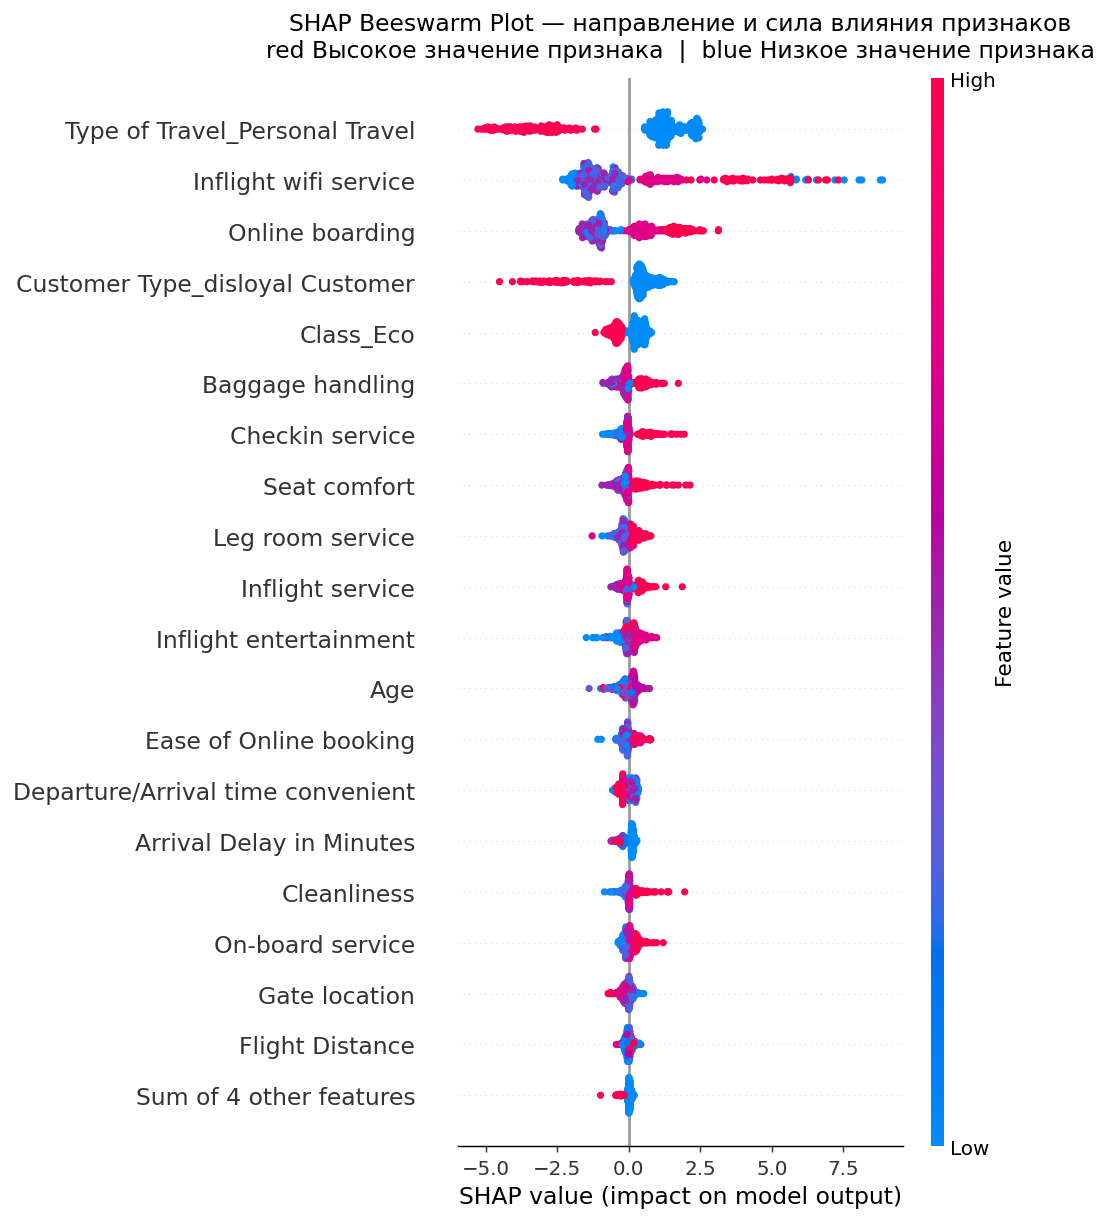

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
shap.plots.beeswarm(
    shap_exp_clean,
    max_display=20,
    show=False
)
plt.title(
    'SHAP Beeswarm Plot — направление и сила влияния признаков\n'
    'red Высокое значение признака  |  blue Низкое значение признака',
    fontsize=13, pad=12
)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

---
 SHAP Dependence Plots — топ-4 драйвера

Топ-4 признака: ['Type of Travel_Personal Travel', 'Inflight wifi service', 'Online boarding', 'Customer Type_disloyal Customer']


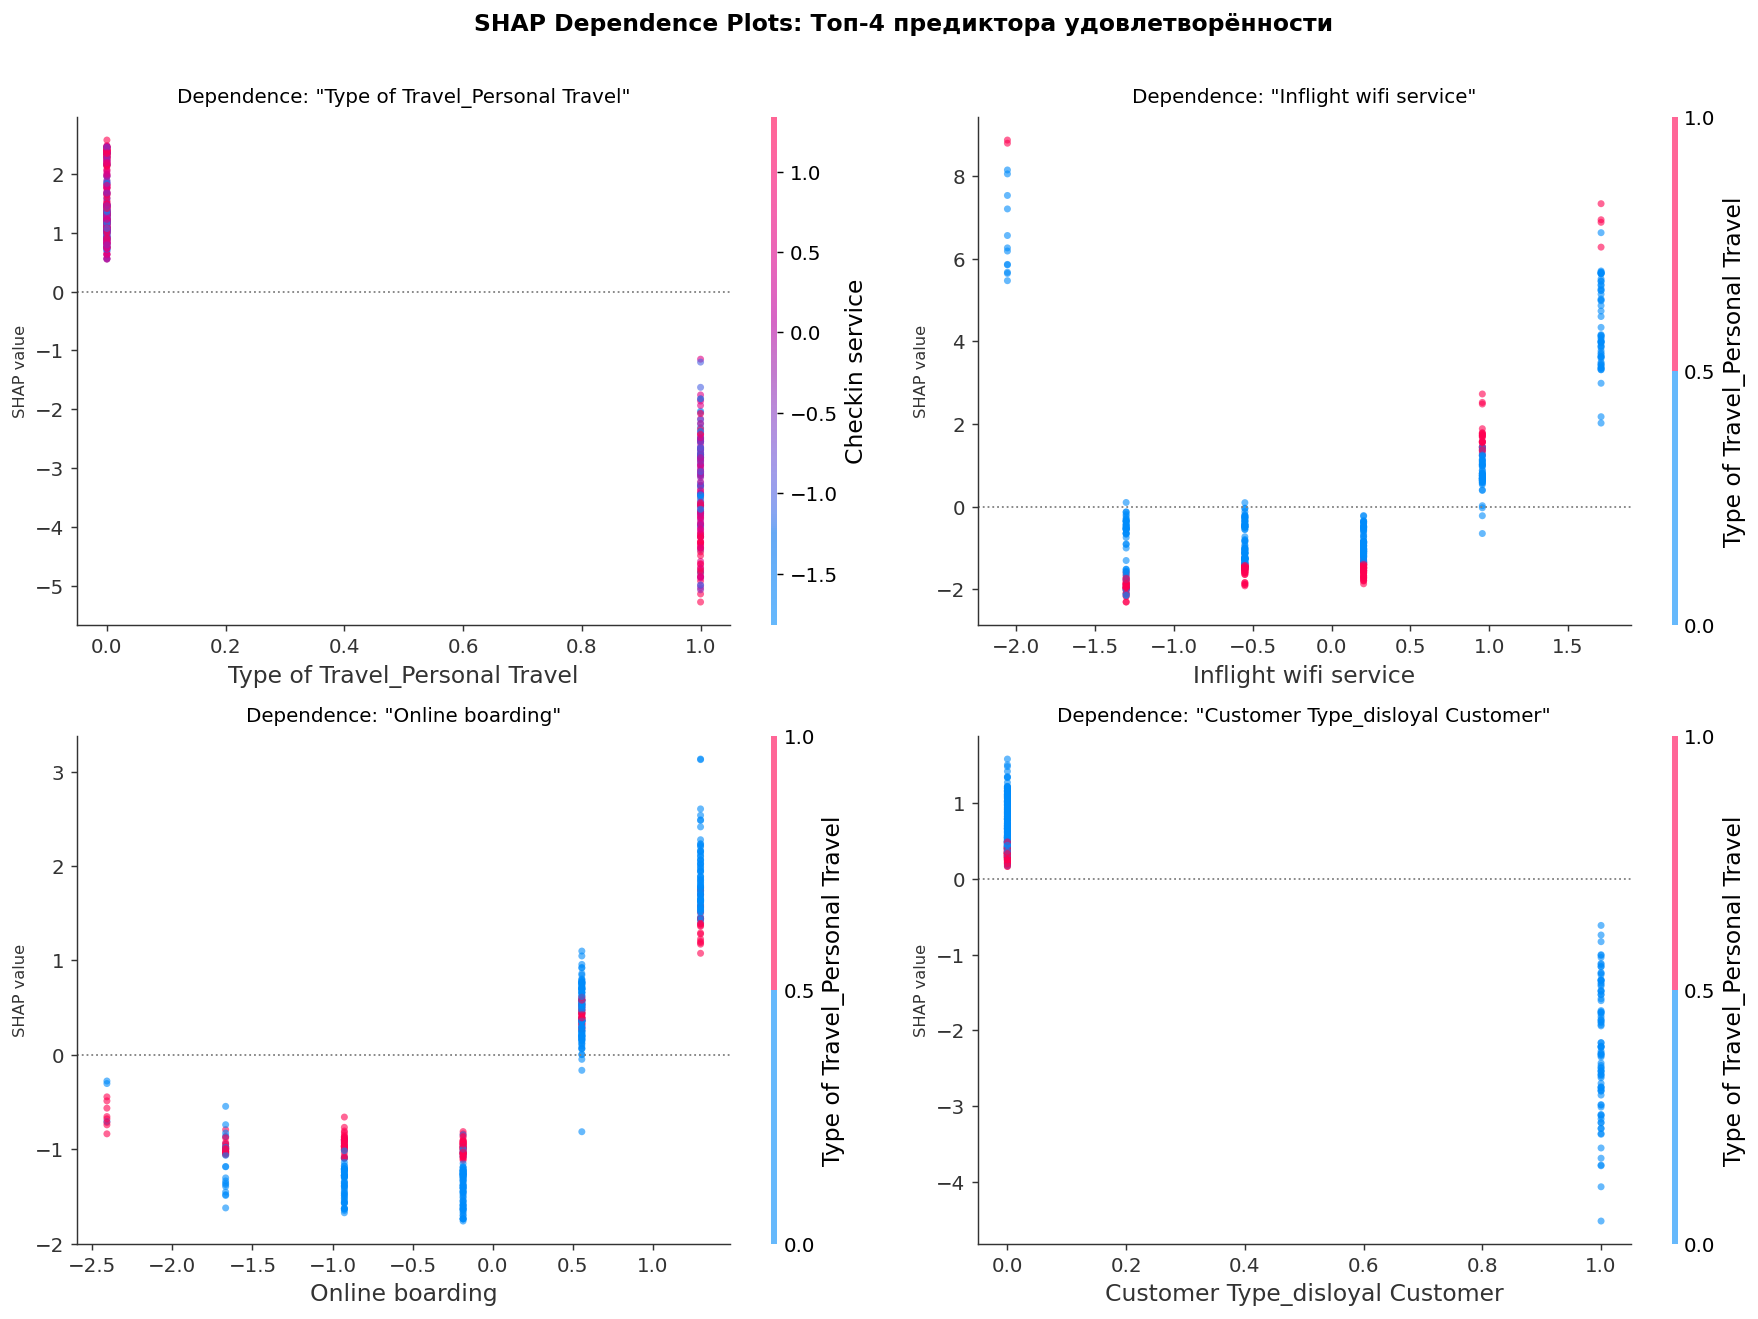

In [9]:
top4_features = mean_shap['Feature'].head(4).tolist()
print(f"Топ-4 признака: {top4_features}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top4_features):
    feat_idx = clean_names.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_vals,
        X_shap_df,
        feature_names=clean_names,
        ax=axes[i],
        show=False,
        alpha=0.6,
        dot_size=15,
        color='#3498db'
    )
    axes[i].set_title(f'Dependence: "{feat}"', fontsize=11, pad=8)
    axes[i].axhline(0, color='gray', linestyle=':', linewidth=1)
    axes[i].set_ylabel(f'SHAP value', fontsize=9)

plt.suptitle(
    'SHAP Dependence Plots: Топ-4 предиктора удовлетворённости',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('shap_dependence_top4.png', dpi=150, bbox_inches='tight')
plt.show()

---
 SHAP Waterfall — объяснение индивидуальных предсказаний

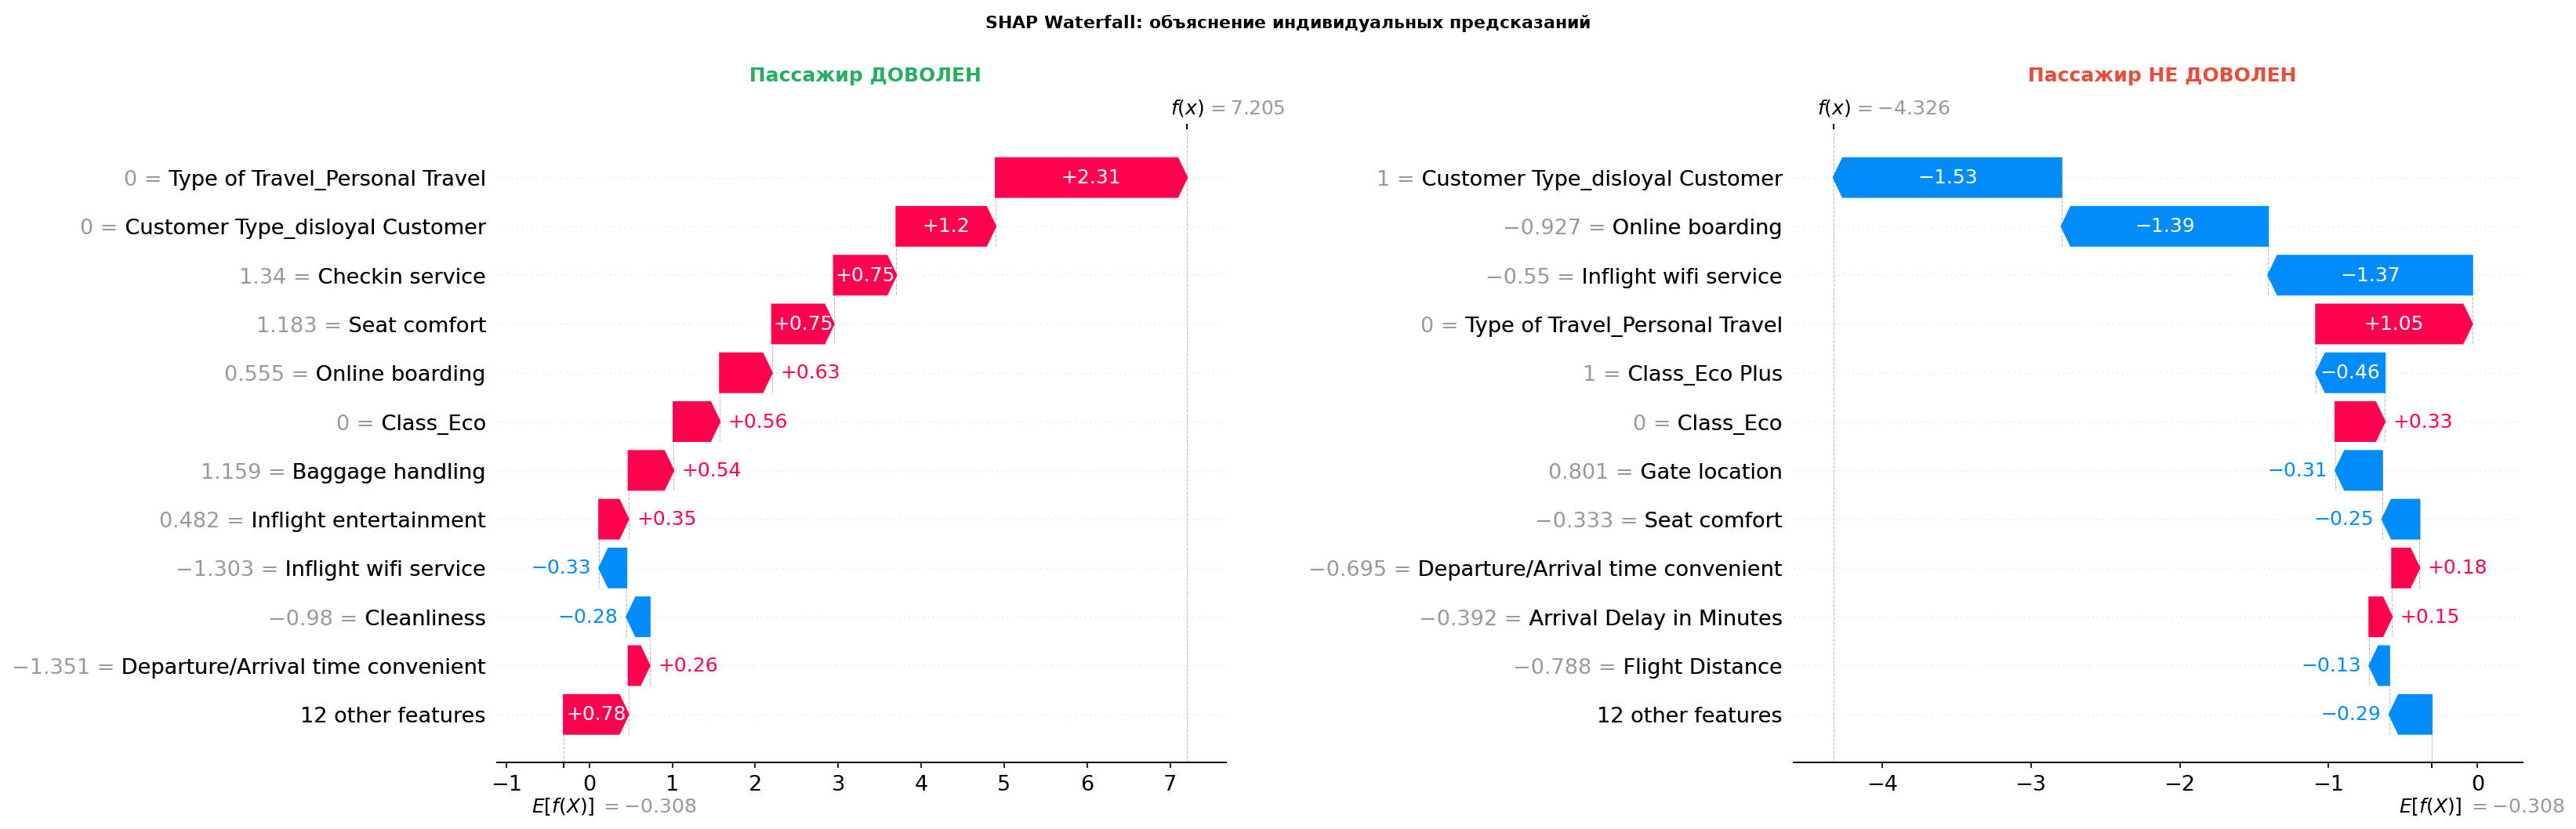

In [10]:
idx_satisfied    = np.where(y_sample.values == 1)[0][0]
idx_dissatisfied = np.where(y_sample.values == 0)[0][0]

imgs = []
for idx, label, color in [
    (idx_satisfied,    ' Пассажир ДОВОЛЕН',    '#27ae60'),
    (idx_dissatisfied, ' Пассажир НЕ ДОВОЛЕН', '#e74c3c')
]:
    shap.plots.waterfall(shap_exp_clean[idx], max_display=12, show=False)
    fig = plt.gcf()
    fig.set_size_inches(8, 7)
    plt.gca().set_title(label, fontsize=12, pad=10, color=color, fontweight='bold')

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    imgs.append(Image.open(buf))
    plt.close(fig)

h = max(i.height for i in imgs)
imgs = [i.resize((int(i.width * h / i.height), h)) for i in imgs]

top = 70
combined = Image.new('RGB', (sum(i.width for i in imgs), h + top), 'white')
x = 0
for i in imgs:
    combined.paste(i, (x, top))
    x += i.width

draw = ImageDraw.Draw(combined)
font_path = fm.findfont(fm.FontProperties(family='sans-serif', weight='bold'))
font = ImageFont.truetype(font_path, 22)

title = 'SHAP Waterfall: объяснение индивидуальных предсказаний'
w = draw.textbbox((0, 0), title, font=font)[2]
draw.text(((combined.width - w) / 2, 15), title, fill='black', font=font)

combined.save('shap_waterfall_individual.png')
combined

---
 SHAP Позитивные vs Негативные факторы

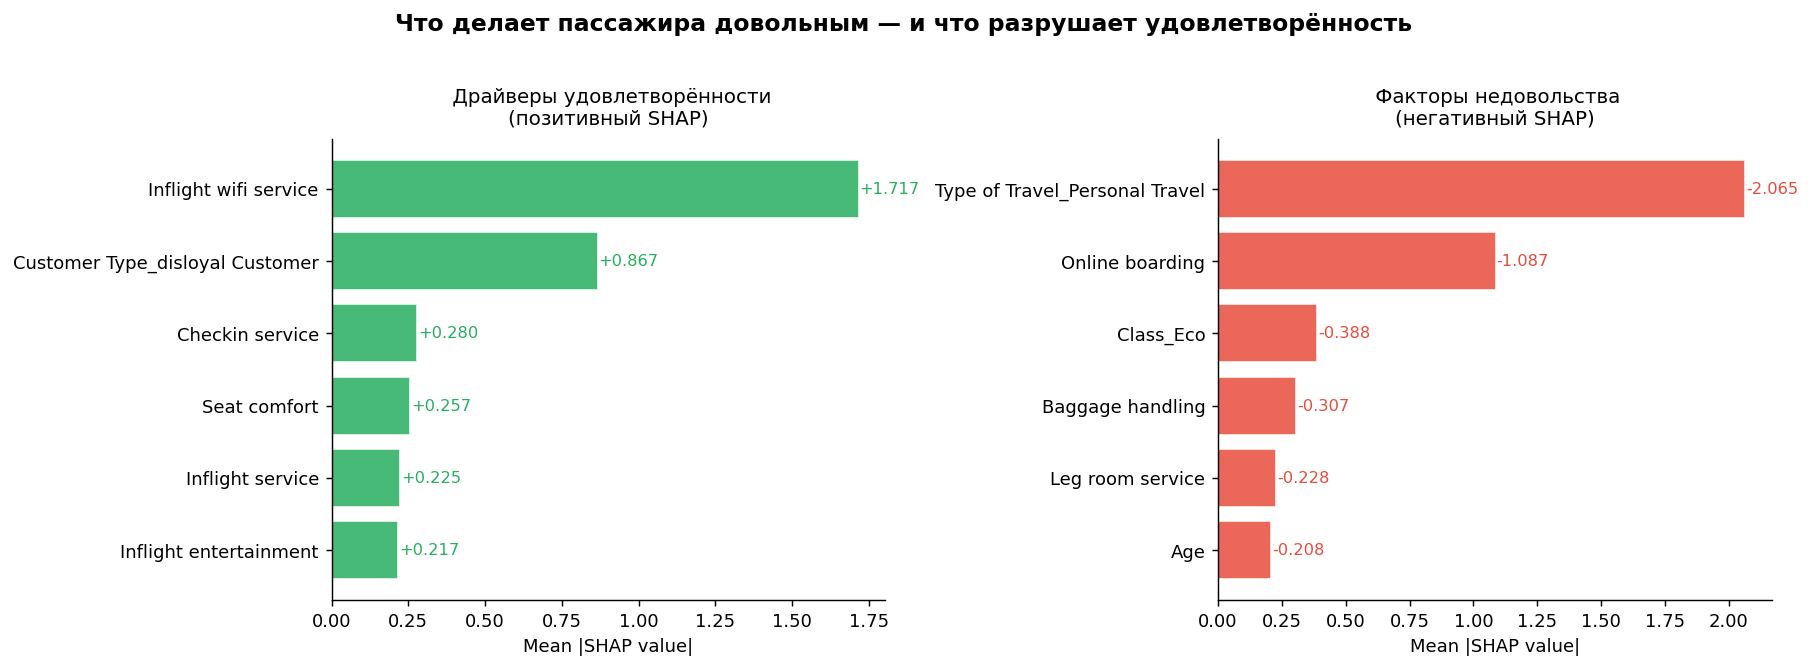


Топ драйверы: ['Inflight wifi service', 'Customer Type_disloyal Customer', 'Checkin service', 'Seat comfort', 'Inflight service', 'Inflight entertainment']
Топ детракторы: ['Type of Travel_Personal Travel', 'Online boarding', 'Class_Eco', 'Baggage handling', 'Leg room service', 'Age']


In [11]:
mean_shap_signed = pd.DataFrame({
    'Feature':       clean_names,
    'Mean SHAP':     shap_vals.mean(axis=0),
    'Mean |SHAP|':   np.abs(shap_vals).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).head(18)

drivers     = mean_shap_signed[mean_shap_signed['Mean SHAP'] >  0].head(6)
detractors  = mean_shap_signed[mean_shap_signed['Mean SHAP'] <= 0].head(6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.barh(
    drivers['Feature'][::-1], drivers['Mean |SHAP|'][::-1],
    color='#27ae60', alpha=0.85, edgecolor='white'
)
for bar in bars:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"+{bar.get_width():.3f}", va='center', fontsize=9, color='#27ae60')
ax.set_title(' Драйверы удовлетворённости\n(позитивный SHAP)', fontsize=11, pad=8)
ax.set_xlabel('Mean |SHAP value|', fontsize=10)

ax = axes[1]
bars = ax.barh(
    detractors['Feature'][::-1], detractors['Mean |SHAP|'][::-1],
    color='#e74c3c', alpha=0.85, edgecolor='white'
)
for bar in bars:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"-{bar.get_width():.3f}", va='center', fontsize=9, color='#e74c3c')
ax.set_title(' Факторы недовольства\n(негативный SHAP)', fontsize=11, pad=8)
ax.set_xlabel('Mean |SHAP value|', fontsize=10)

plt.suptitle(
    'Что делает пассажира довольным — и что разрушает удовлетворённость',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('shap_drivers_detractors.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nТоп драйверы:", drivers['Feature'].tolist())
print("Топ детракторы:", detractors['Feature'].tolist())